# QFAN training — Feynman equations + optional toy demo

Trains **QFAN** (quantum-inspired function approximator) on the **Feynman physics benchmark** (`qfun.feynman_dataset`): inputs are normalized to $[-1,1]$ per variable, targets are the equation values. Uses `train_feynman_equation` (same split/training pattern as `run_feynman_benchmark`).

Later cells show **learned basis profiles** and a small **signed-encoding** sanity check. An optional **toy** $y=\sin x + 0.3x$ block is kept for comparison.

In [29]:
import sys
from pathlib import Path

# Repo root (works if cwd is notebooks/ or QFun/)
for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "qfun").is_dir():
        _root = str(_p.resolve())
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break

import numpy as np
import matplotlib.pyplot as plt
import pennylane.numpy as pnp

from qfun import feynman_dataset
from qfun.qfan import mode_a_signed_encode, reconstruct_mode_a_signed, train_feynman_equation
from scripts.train_qfan_demo import target_function, train_model


In [ ]:
# Pick any id from feynman_dataset.list_equations() (e.g. "I.12.11" = 1 + a*sin(theta))
FEYNMAN_EQ_ID = "II.35.18"

res = train_feynman_equation(
    FEYNMAN_EQ_ID,
    n_samples=512,
    test_split=0.2,
    data_seed=0,
    num_functions=3,
    n_qubits=5,
    mode="mode_a",
    steps=150,
    lr=0.05,
)
model = res.model
losses = res.losses

print(f"{res.eq_id}: {res.formula}")
print(f"variables={list(res.variables)}  train_MSE={res.train_mse:.6f}  test_MSE={res.test_mse:.6f}")
res.x_train.shape, res.y_train.shape

II.35.18: n₀ / (exp(a) + exp(−a))
variables=['n0', 'a']  train_MSE=0.000382  test_MSE=0.000349


((409, 2), (409,))

In [31]:
# Optional: toy target y = sin(x) + 0.3 x on [-1,1] (uncomment to run)
# model, x_train, y_train, losses = train_model(
#     num_functions=3, n_qubits=5, mode="mode_a", n_samples=128, steps=150, lr=0.05
# )
# res = None  # toy path: plots below use model/losses only

losses[0], losses[-1]

(np.float64(0.3246033318131142), np.float64(0.00040453012960705003))

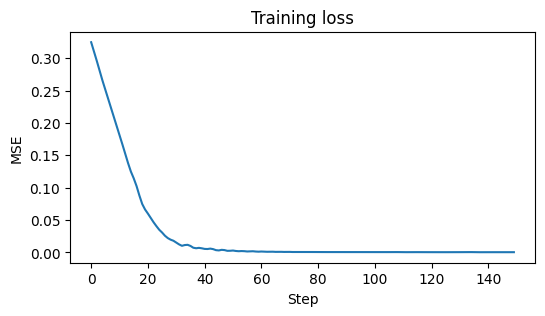

In [32]:
plt.figure(figsize=(6,3))
plt.plot(losses)
plt.title('Training loss')
plt.xlabel('Step')
plt.ylabel('MSE')
plt.show()

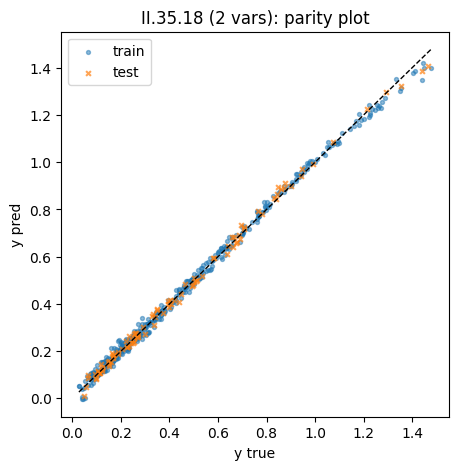

In [33]:
def _denorm_axis(x_norm_col, lo, hi):
    return (np.asarray(x_norm_col) + 1.0) * (hi - lo) / 2.0 + lo


if res is not None and len(res.variables) == 1:
    v0 = res.variables[0]
    lo, hi = res.domains[v0]
    x_line = np.linspace(-1.0, 1.0, 256).reshape(-1, 1)
    x_raw = _denorm_axis(x_line[:, 0], lo, hi)
    eqn = feynman_dataset.get_equation(res.eq_id)
    y_true = np.asarray(eqn.func(x_raw))
    y_pred = np.asarray(model.forward_batch(pnp.array(x_line)))
    x_tr = _denorm_axis(res.x_train[:, 0], lo, hi)
    x_te = _denorm_axis(res.x_test[:, 0], lo, hi)
    plt.figure(figsize=(6, 4))
    plt.scatter(x_tr, np.asarray(res.y_train), s=10, alpha=0.4, label="train")
    plt.scatter(x_te, np.asarray(res.y_test), s=14, alpha=0.6, label="test", marker="x")
    plt.plot(x_raw, y_true, label="Feynman", lw=2)
    plt.plot(x_raw, y_pred, label="QFAN", lw=2)
    plt.xlabel(v0)
    plt.ylabel("y")
    plt.legend()
    plt.title(f"{res.eq_id}: {res.formula}")
    plt.show()
elif res is not None:
    y_pred_tr = np.asarray(model.forward_batch(pnp.array(res.x_train)))
    y_pred_te = np.asarray(model.forward_batch(pnp.array(res.x_test)))
    plt.figure(figsize=(5, 5))
    plt.scatter(res.y_train, y_pred_tr, s=8, alpha=0.5, label="train")
    plt.scatter(res.y_test, y_pred_te, s=12, alpha=0.7, label="test", marker="x")
    lo = min(float(res.y_train.min()), float(res.y_test.min()))
    hi = max(float(res.y_train.max()), float(res.y_test.max()))
    plt.plot([lo, hi], [lo, hi], "k--", lw=1)
    plt.xlabel("y true")
    plt.ylabel("y pred")
    plt.legend()
    plt.title(f"{res.eq_id} ({len(res.variables)} vars): parity plot")
    plt.show()
else:
    x_line = np.linspace(-1, 1, 256).reshape(-1, 1)
    y_true = target_function(x_line[:, 0])
    y_pred = np.asarray(model.forward_batch(pnp.array(x_line)))
    plt.figure(figsize=(6, 4))
    plt.scatter(np.asarray(x_train[:, 0]), np.asarray(y_train), s=10, alpha=0.4, label="train")
    plt.plot(x_line[:, 0], y_true, label="target", lw=2)
    plt.plot(x_line[:, 0], y_pred, label="QFAN", lw=2)
    plt.legend()
    plt.title("Toy: trained QFAN vs target")
    plt.show()


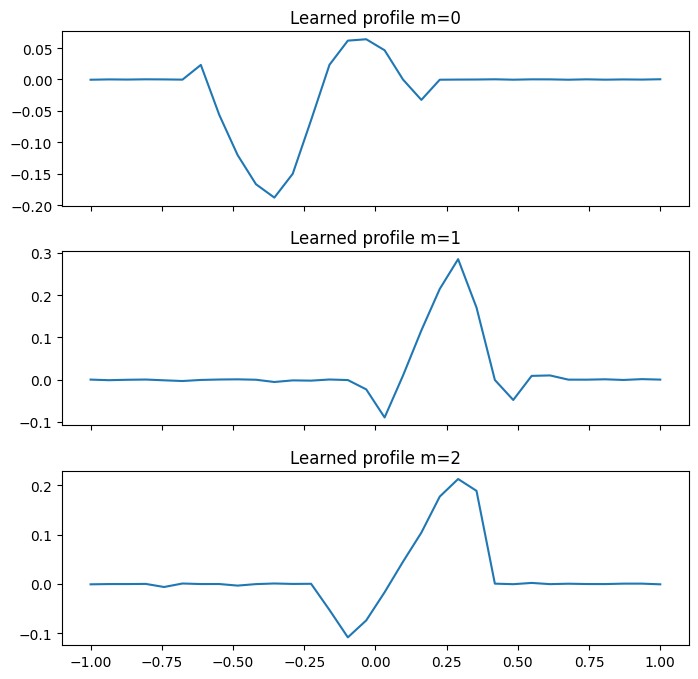

In [34]:
fig, axes = plt.subplots(model.num_functions, 1, figsize=(7, 2.3*model.num_functions), sharex=True)
for m in range(model.num_functions):
    axes[m].plot(np.asarray(model.x_grid), np.asarray(model.get_profile(m)))
    axes[m].set_title(f'Learned profile m={m}')
plt.tight_layout()
plt.show()

max |reconstruction - f/sum|f|| = 3.97e-13


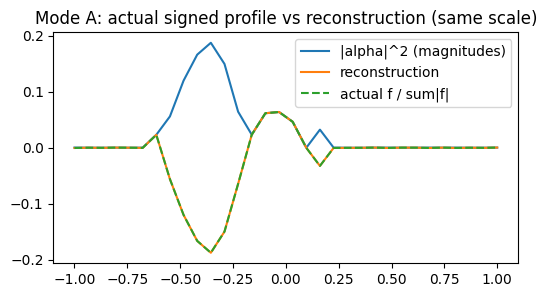

In [35]:
m = 0
grid_vals = np.asarray(model.grid_values[m])
alpha, sign_bits = mode_a_signed_encode(grid_vals)
q_hat = reconstruct_mode_a_signed(alpha, sign_bits)

# Exact identity (up to float noise): q_hat_i = grid_vals_i / sum_j |grid_vals_j|
l1 = np.sum(np.abs(grid_vals)) + 1e-12
f_normalized = grid_vals / l1
max_abs_err = float(np.max(np.abs(q_hat - f_normalized)))
print(f"max |reconstruction - f/sum|f|| = {max_abs_err:.2e}")

plt.figure(figsize=(6, 3))
plt.plot(np.asarray(model.x_grid), np.abs(alpha) ** 2, label="|alpha|^2 (magnitudes)")
plt.plot(np.asarray(model.x_grid), q_hat, label="reconstruction")
plt.plot(np.asarray(model.x_grid), f_normalized, "--", label="actual f / sum|f|")
plt.legend()
plt.title("Mode A: actual signed profile vs reconstruction (same scale)")
plt.show()